In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import workCon
import os
from eval import get_model_from_run
from tqdm import tqdm
import ipdb
import traceback
import random
import math
import generate_dataset
from scipy.integrate import solve_ivp
import pickle
import plotly.graph_objects as go
from IPython.display import HTML

/home/esmith/.conda/envs/icl_ebonye_pendulum/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def mse(theta_model, thetadot_model, theta_rk4, thetadot_rk4):
    """
    Calculates the Mean Squared Error (MSE) between the predicted and true states.

    Args:
        theta_model (np.ndarray or list): Model's predicted theta 
        thetadot_model (np.ndarray or list): Model's predicted thetadot 
        theta_rk4 (np.ndarray or list): True theta using RK4
        thetadot_rk4 (np.ndarray or list): True thetadot using RK4

    Returns:
        float: The computed MSE value, representing the average squared difference between 
        the predicted and true states.
    """
    xs_pred = torch.tensor(np.column_stack((theta_model, thetadot_model)), dtype=torch.float32)
    xs_true = torch.tensor(np.column_stack((theta_rk4, thetadot_rk4)), dtype=torch.float32)
    return (xs_true - xs_pred).pow(2).mean().item()

def load_data(data_path):
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    return data


In [3]:
model_run_id = "15bf641c-dbc0-4f2f-b62f-fe04f568aacb"
step = 185000 
numberpend = 100 #200 #5
data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_indistr_alexcode.pkl'
# lambda1s, lambda2s, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# cartmasses, polemasses, polelengths, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
# print(f"Loaded data from {data_path}")

In [4]:
def _total_energy(theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    # small helper (matches your conventions)
    c2 = np.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2
    D = np.array([[D11, D12],[D12, D22]])
    dq = np.array([d1, d2])
    KE = 0.5 * dq @ (D @ dq)
    # T1 = 0.5 * I1 * d1**2
    # T2 = 0.5 * (m2 * l1**2 + I2 + 2*m2 * l1 * lc2 * c2) * d1**2 + 0.5 * I2 * d2**2 + (I2 + m2* l1 * lc2 * c2) * d1 * d2
    # KE = T1 + T2

    # U = -m1 * g * lc1 * np.cos(theta1 - np.pi/2.0) - m2 * g * (l1 * np.cos(theta1 - np.pi/2.0) + lc2 * np.cos(theta1 + theta2 - np.pi/2.0))
    # PE = U  # potential energy (up is negative; consistent with physics)

    # potential energy (up is positive; consistent with gym)
    y1 = lc1 * np.cos(theta1 - np.pi/2.0)
    y_tip = l1 * np.cos(theta1 - np.pi/2.0)
    y2 = y_tip + lc2 * np.cos(theta1 + theta2 - np.pi/2.0)
    PE = m1 * 9.81 * y1 + m2 * 9.81 * y2
    # return KE + PE
    return KE, PE


def _total_energy_batch(theta1, theta2, d1, d2,
                  m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    """
    Vectorized total energy for acrobot (PyTorch version).
    
    Parameters:
        theta1, theta2, d1, d2 : float or tensor, shape (N,) or scalar
        m1, m2, l1, lc1, lc2, I1, I2 : float or tensor, shape (N,) or scalar
        g : gravity (float)
    
    Returns:
        Total energy (N,) tensor if inputs are batched, else scalar tensor.
    """

    # Convert everything to tensors on the same device/dtype
    device = (theta1.device if isinstance(theta1, torch.Tensor)
              else torch.device("cuda:0"))
    dtype = (theta1.dtype if isinstance(theta1, torch.Tensor)
             else torch.float32)

    def ensure_tensor(x):
        return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = map(
        ensure_tensor, (theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2)
    )

    # Broadcast to common shape
    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = torch.broadcast_tensors(
        theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2
    )

    # Kinetic energy
    c2 = torch.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2

    dq = torch.stack([d1, d2], dim=-1)  # (N, 2)
    D = torch.stack([
        torch.stack([D11, D12], dim=-1),
        torch.stack([D12, D22], dim=-1)
    ], dim=-2)  # (N, 2, 2)

    KE = 0.5 * torch.einsum("...i,...ij,...j->...", dq, D, dq)

    

    # Potential energy
    y1 = lc1 * torch.cos(theta1 - torch.pi/2.0)
    y_tip = l1 * torch.cos(theta1 - torch.pi/2.0)
    y2 = y_tip + lc2 * torch.cos(theta1 + theta2 - torch.pi/2.0)

    PE = m1 * g * y1 + m2 * g * y2

    return KE.cpu().numpy(), PE.cpu().numpy()

In [37]:
# def cost_metric()

def stability_metric(states, K=20):
    """
    Computes the stability metric for a given set of states.

    Args:
        states (np.ndarray): Array of shape (T, state_dim) representing the states over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        float: The computed stability metric, representing the average deviation from goal state of last K steps.
    """
    if states.shape[0] < K + 1:
        raise ValueError("The number of time steps in states must be greater than K.")
    
    # Extract the last K states
    final_states = states[-K:]

    # convert angles to cosine and sine
    final_states = final_states.cpu().numpy() if torch.is_tensor(final_states) else final_states
    xs_cos1 = np.cos(final_states[:, 0])
    xs_sin1 = np.sin(final_states[:, 0])
    xs_cos2 = np.cos(final_states[:, 1])
    xs_sin2 = np.sin(final_states[:, 1])
    xs1dot = final_states[:, 2]
    xs2dot = final_states[:, 3]
    final_states_transformed = np.column_stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot))
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]

    # Compute the Euclidean distance from the goal state for each of the last K states
    distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
    return np.mean(distances)

def stability_metric_batch(states_batch, K=20):
    """
    Computes the stability metric for a batch of states.

    Args:
        states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        np.ndarray: Array of shape (N,) containing the stability metric for each sequence.
    """
    if isinstance(states_batch, torch.Tensor):
        states_batch = states_batch.cpu().numpy()
    
    final_states = states_batch[:, -K:, :]
    xs_cos1 = np.cos(final_states[:, :, 0])
    xs_sin1 = np.sin(final_states[:, :, 0])
    xs_cos2 = np.cos(final_states[:, :, 1])
    xs_sin2 = np.sin(final_states[:, :, 1])
    xs1dot = final_states[:, :, 2]
    xs2dot = final_states[:, :, 3]
    final_states_transformed = np.stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot), axis=-1)

    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    distances = np.linalg.norm(final_states_transformed - goal_state, axis=-1)
    return np.mean(distances, axis=1)

def swinging_metric_batch(control_labels):
    """
    Computes the swinging metric for a batch of control labels.

    Args:
        control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of control inputs over time.
    Returns:
        np.ndarray: Array of shape (N,) containing the swinging metric for each sequence.
    """
    if isinstance(control_labels, torch.Tensor):
        control_labels = control_labels.cpu().numpy()
    
    # Compute the sum of time steps where controller is in swing-up mode (control label == 0)
    mask = (control_labels == 0)
    swinging_durations = np.sum(mask, axis=1)
    return swinging_durations

def swinging_difference_batch(true_control_labels, predicted_control_labels):
    """
    Compares swinging of true controller versus predicted control sequence.

    Args:
        true_control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of true control inputs over time.
        predicted_control_labels (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of predicted control inputs over time.

    """
    if isinstance(true_control_labels, torch.Tensor):
        true_control_labels = true_control_labels.cpu().numpy()
    if isinstance(predicted_control_labels, torch.Tensor):
        predicted_control_labels = predicted_control_labels.cpu().numpy()

    # Compute the difference in swinging durations
    true_swinging = swinging_metric_batch(true_control_labels)
    predicted_swinging = swinging_metric_batch(predicted_control_labels)
    return np.abs(true_swinging - predicted_swinging)

def stability_fraction_batch(predicted_states, K=20, threshold=0.1):
    """
    Computes the fraction of systems that are stable in the last K time steps.
    Args:
        predicted_states (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        K (int): Number of final time steps to consider for the stability metric.
        threshold (float): Distance threshold to consider a system as stable.
    Returns:
        float: Fraction of systems that are stable.
    """
    if isinstance(predicted_states, torch.Tensor):
        predicted_states = predicted_states.cpu().numpy()
    
    N = predicted_states.shape[0]
    stable_count = 0
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    for i in range(N):
        final_states = predicted_states[i, -K:, :]
        xs_cos1 = np.cos(final_states[:, 0])
        xs_sin1 = np.sin(final_states[:, 0])
        xs_cos2 = np.cos(final_states[:, 1])
        xs_sin2 = np.sin(final_states[:, 1])
        xs1dot = final_states[:, 2]
        xs2dot = final_states[:, 3]
        final_states_transformed = np.column_stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot))
        distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
        # import pdb; pdb.set_trace()
        if np.all(distances < threshold):
            stable_count += 1
    return stable_count / N

def stability_fraction_all_contexts_batch(predicted_states_dict, K=20, threshold=0.1):
    """
    Computes the fraction of systems that are stable in the last K time steps for at least one context.
    Args:
        predicted_states_dict (dict): Dictionary where keys are context identifiers and values are arrays of shape (N, T, state_dim) representing N sequences of states over time for that context.
        K (int): Number of final time steps to consider for the stability metric.
        threshold (float): Distance threshold to consider a system as stable.
    Returns:
        float: Fraction of systems that are stable in at least one context.
    """
    contexts = list(predicted_states_dict.keys())
    N = predicted_states_dict[contexts[0]].shape[0]
    stable_count = 0
    goal_state = np.array([-1, 0, 1, 0, 0, 0]) # [cos(pi), sin(pi), cos(0), sin(0), 0, 0]
    for i in range(N):
        is_stable_in_any_context = False
        for context in contexts:
            predicted_states = predicted_states_dict[context].cpu().numpy() if torch.is_tensor(predicted_states_dict[context]) else predicted_states_dict[context]
            final_states = predicted_states[i, -K:, :]
            xs_cos1 = np.cos(final_states[:, 0])
            xs_sin1 = np.sin(final_states[:, 0])
            xs_cos2 = np.cos(final_states[:, 1])
            xs_sin2 = np.sin(final_states[:, 1])
            xs1dot = final_states[:, 2]
            xs2dot = final_states[:, 3]
            final_states_transformed = np.column_stack((xs_cos1, xs_sin1, xs_cos2, xs_sin2, xs1dot, xs2dot))
            distances = np.linalg.norm(final_states_transformed - goal_state, axis=1)
            if np.all(distances < threshold):
                is_stable_in_any_context = True
                break
        if is_stable_in_any_context:
            stable_count += 1
    return stable_count / N


def energy_metric_batch(true_states_batch, predicted_states_batch, link_lengths1, link_lengths2, link_masses1, link_masses2):
    """
    Computes the difference in total energy for true vs predicted trajectories.
    Args:
        true_states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of true states over time.
        predicted_states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of predicted states over time.
        link_lengths1 (float or np.ndarray): Length(s) of the first link(s).
        link_lengths2 (float or np.ndarray): Length(s) of the second link(s).
        link_masses1 (float or np.ndarray): Mass(es) of the first link(s).
        link_masses2 (float or np.ndarray): Mass(es) of the second link(s).
    Returns:
        np.ndarray: Array of shape (N,) containing the average energy difference for each sequence.
    """
    if isinstance(true_states_batch, torch.Tensor):
        true_states_batch = true_states_batch.cpu().numpy()
    if isinstance(predicted_states_batch, torch.Tensor):
        predicted_states_batch = predicted_states_batch.cpu().numpy()
    
    theta1_true = true_states_batch[:, :, 0]
    theta2_true = true_states_batch[:, :, 1]
    d1_true = true_states_batch[:, :, 2]
    d2_true = true_states_batch[:, :, 3]

    theta1_pred = predicted_states_batch[:, :, 0]
    theta2_pred = predicted_states_batch[:, :, 1]
    d1_pred = predicted_states_batch[:, :, 2]
    d2_pred = predicted_states_batch[:, :, 3]

    # KE_true, PE_true = _total_energy_batch(theta1_true, theta2_true, d1_true, d2_true,
    #                                        link_masses1, link_masses2,
    #                                        link_lengths1, link_lengths1/2, link_lengths2/2,
    #                                        (1/12)*link_masses1*link_lengths1**2,
    #                                        (1/12)*link_masses2*link_lengths2**2)
    # KE_pred, PE_pred = _total_energy_batch(theta1_pred, theta2_pred, d1_pred, d2_pred,
    #                                        link_masses1, link_masses2,
    #                                        link_lengths1, link_lengths1/2, link_lengths2/2,
    #                                        (1/12)*link_masses1*link_lengths1**2,
    #                                        (1/12)*link_masses2*link_lengths2**2)

    for i in range(true_states_batch.shape[1]):
        KE_true, PE_true = _total_energy_batch(theta1_true[:, i], theta2_true[:, i], d1_true[:, i], d2_true[:, i],
                                           link_masses1, link_masses2,
                                           link_lengths1, link_lengths1/2, link_lengths2/2,
                                           (1/12)*link_masses1*link_lengths1**2,
                                           (1/12)*link_masses2*link_lengths2**2)
        KE_pred, PE_pred = _total_energy_batch(theta1_pred[:, i], theta2_pred[:, i], d1_pred[:, i], d2_pred[:, i],
                                           link_masses1, link_masses2,
                                           link_lengths1, link_lengths1/2, link_lengths2/2,
                                           (1/12)*link_masses1*link_lengths1**2,
                                           (1/12)*link_masses2*link_lengths2**2)
        if i == 0:
            KE_true_all = KE_true[:, None]
            PE_true_all = PE_true[:, None]
            KE_pred_all = KE_pred[:, None]
            PE_pred_all = PE_pred[:, None]
        else:
            KE_true_all = np.concatenate((KE_true_all, KE_true[:, None]), axis=1)
            PE_true_all = np.concatenate((PE_true_all, PE_true[:, None]), axis=1)
            KE_pred_all = np.concatenate((KE_pred_all, KE_pred[:, None]), axis=1)
            PE_pred_all = np.concatenate((PE_pred_all, PE_pred[:, None]), axis=1)

    # total_energy_true = KE_true + PE_true
    # total_energy_pred = KE_pred + PE_pred

    # energy_diff = np.abs(total_energy_true - total_energy_pred)
    total_energy_true = KE_true_all + PE_true_all
    total_energy_pred = KE_pred_all + PE_pred_all
    energy_diff = np.abs(total_energy_true - total_energy_pred)
    # import pdb; pdb.set_trace()
    ## do l2 instead of l1
    
    return np.mean(energy_diff, axis=1)

def evaluate_metrics(states_batch, control_labels_batch, K=20):
    """
    Evaluates both stability and swinging metrics for a batch of states and control labels.

    Args:
        states_batch (np.ndarray or torch.Tensor): Array of shape (N, T, state_dim) representing N sequences of states over time.
        control_labels_batch (np.ndarray or torch.Tensor): Array of shape (N, T, control_dim) representing N sequences of control inputs over time.
        K (int): Number of final time steps to consider for the stability metric.
    Returns:
        tuple: Two np.ndarrays of shape (N,) containing the stability and swinging metrics for each sequence.
    """
    stability_metrics = stability_metric_batch(states_batch, K)
    swinging_metrics = swinging_metric_batch(control_labels_batch)
    return stability_metrics, swinging_metrics
    

In [ ]:
steps_list = [50000, 75000, 100000, 125000, 145000, 185000, 200000, 230000, 235000, 240000, 245000]
context_lengths = [1, 10, 20, 30, 40, 50]


results = {}
metrics = ['stability', 'swinging', 'energy', 'stability_fraction']
for metric in metrics:
    results[metric] = {}

# # create prediction dictionary
# predicted_states_dict = {step: {} for step in steps_list}
# for step in steps_list:
#     data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_indistr_alexcode.pkl'
#     link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
#     print(f"Loaded data from {data_path}")
#     for context in context_lengths:
#         pred_traj = torch.stack(phase_data[context])
#         predicted_states_dict[step][context] = pred_traj

# print(f"predicted_states_dict keys: {predicted_states_dict.keys()}")
# print(f"predicted_states_dict[{steps_list[0]}] keys: {predicted_states_dict[steps_list[0]].keys()}")


# just context 30 for now
context = 1
for step in steps_list:
    data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_indistr_alexcode.pkl'
    link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
    print(f"Loaded data from {data_path}")

    pred_traj = torch.stack(phase_data[context])
    
    stability_metrics, swinging_metrics = evaluate_metrics(pred_traj, torch.stack(controls_data[context])[:,:,-1], K=100)
    
    ground_truth_data_controls = data_and_controls[0]
    ground_truth_control_labels = [ground_truth_data_controls[i][1][:,1][:-1] for i in range(len(ground_truth_data_controls))]
    true_traj = [ground_truth_data_controls[i][0] for i in range(len(ground_truth_data_controls))]
    true_traj = np.stack(true_traj)
    # import pdb; pdb.set_trace()
    energy_metric = energy_metric_batch(torch.tensor(true_traj), pred_traj, np.stack(link_lengths1), np.stack(link_lengths2), np.stack(link_masses1), np.stack(link_masses2))
    # import pdb; pdb.set_trace()
    # swinging_compare_metrics = swinging_difference_batch(np.stack(ground_truth_control_labels), torch.stack(controls_data[context])[:,:,-1])

    stability_fraction = stability_fraction_batch(pred_traj, K=20, threshold=0.1)

    median_stability = np.median(stability_metrics)
    mean_stability = np.mean(stability_metrics)
    twentyfifth_percentile = np.percentile(stability_metrics, 25)
    seventyfifth_percentile = np.percentile(stability_metrics, 75)

    median_swinging = np.median(swinging_metrics)
    mean_swinging = np.mean(swinging_metrics)
    twentyfifth_swinging = np.percentile(swinging_metrics, 25)
    seventyfifth_swinging = np.percentile(swinging_metrics, 75)

    median_energy = np.median(energy_metric)
    mean_energy = np.mean(energy_metric)
    twentyfifth_energy = np.percentile(energy_metric, 25)
    seventyfifth_energy = np.percentile(energy_metric, 75)

    results['stability'][step] = {
        'median': median_stability,
        '25th_percentile': twentyfifth_percentile,
        '75th_percentile': seventyfifth_percentile,
        'mean': mean_stability
    }

    results['swinging'][step] = {
        'median': median_swinging,
        '25th_percentile': twentyfifth_swinging,
        '75th_percentile': seventyfifth_swinging,
        'mean': mean_swinging

    }

    results['energy'][step] = {
        'median': median_energy,
        '25th_percentile': twentyfifth_energy,
        '75th_percentile': seventyfifth_energy,
        'mean': mean_energy
    }
    results['stability_fraction'][step] = stability_fraction

    # results['swinging_compare'][step] = {
    #     'median': np.median(swinging_compare_metrics),
    #     '25th_percentile': np.percentile(swinging_compare_metrics, 25),
    #     '75th_percentile': np.percentile(swinging_compare_metrics, 75),
    #     'mean': np.mean(swinging_compare_metrics)
    # }



    





Loaded data from inference_run/mse_control_50000_15bf641c-dbc0-4f2f-b62f-fe04f568aacb/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_75000_15bf641c-dbc0-4f2f-b62f-fe04f568aacb/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_100000_15bf641c-dbc0-4f2f-b62f-fe04f568aacb/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_125000_15bf641c-dbc0-4f2f-b62f-fe04f568aacb/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_145000_15bf641c-dbc0-4f2f-b62f-fe04f568aacb/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_185000_15bf641c-dbc0-4f2f-b62f-fe04f568aacb/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data from inference_run/mse_control_200000_15bf641c-dbc0-4f2f-b62f-fe04f568aacb/results_maxcontext50_numpends100_indistr_alexcode.pkl
Loaded data fro

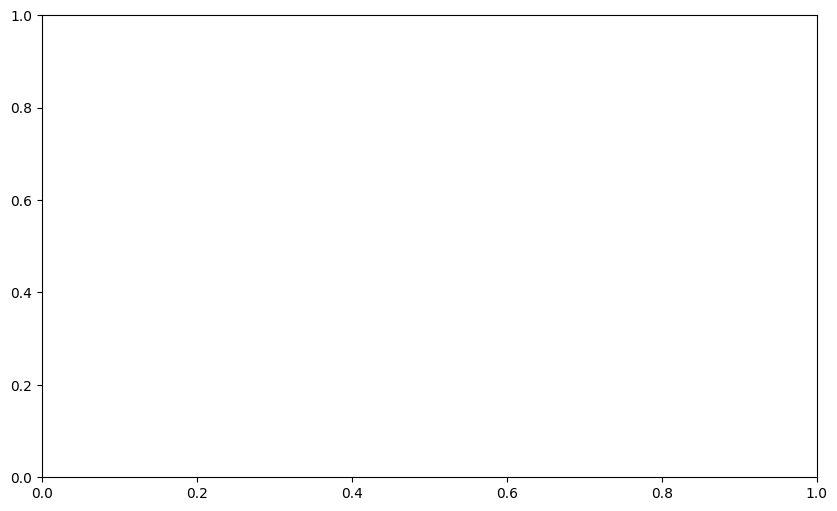

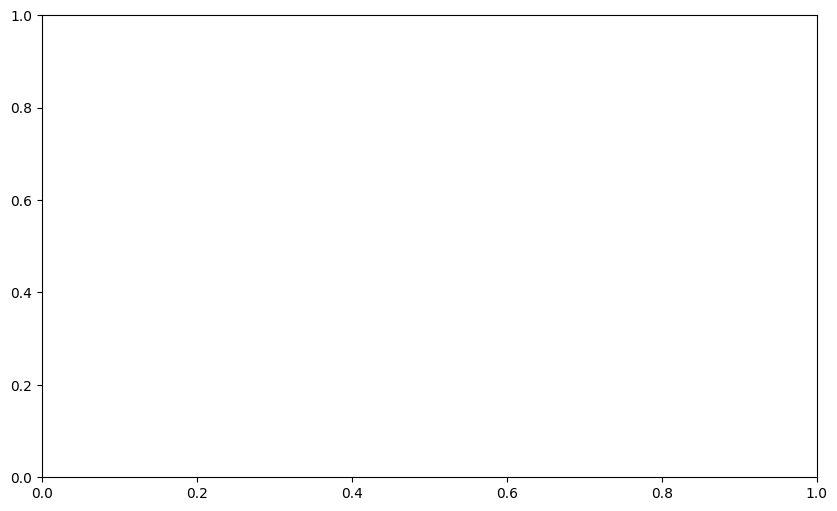

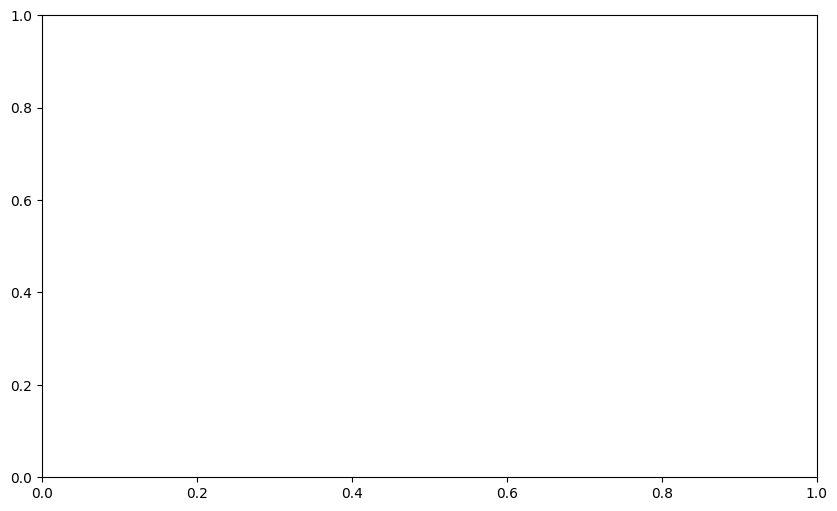

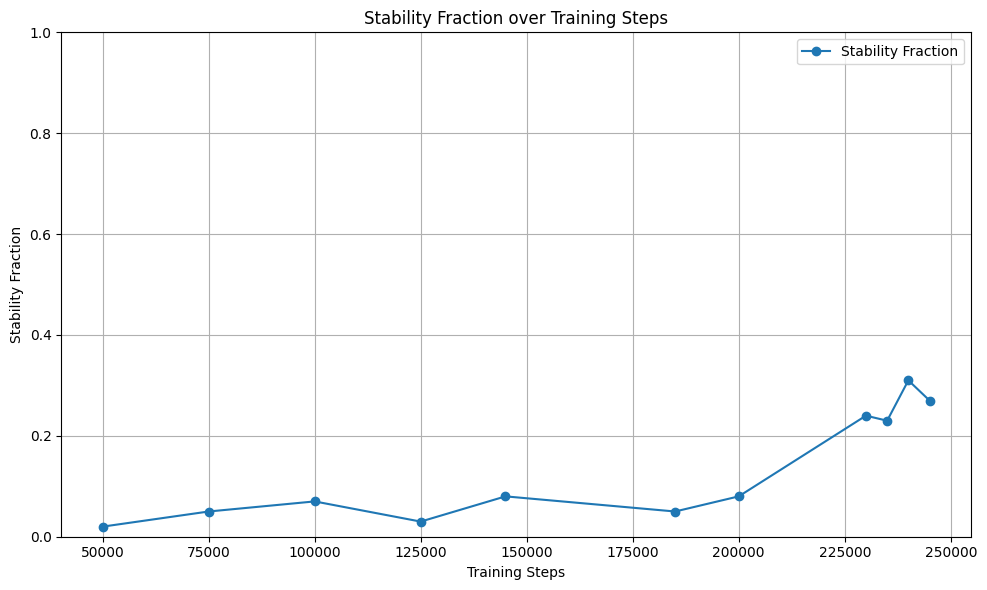

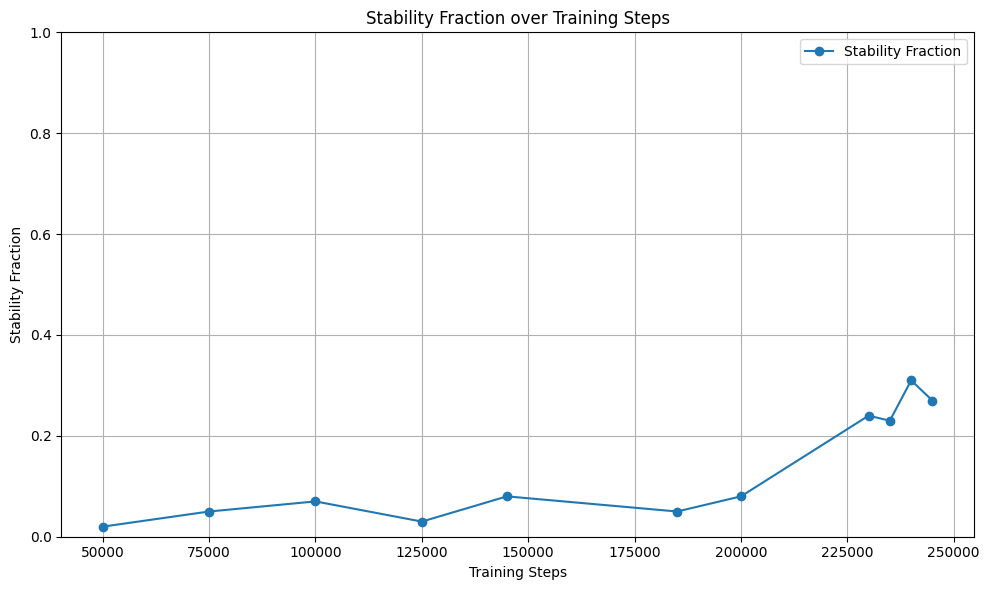

In [29]:
# visulaize results
import matplotlib.pyplot as plt
import pandas as pd

# prepare data for plotting

data = []


for step in steps_list:
    for metric in metrics:
        # print(f"step: {step}, metric: {metric}")
        if metric == 'stability_fraction':
            data.append({
                'metric': metric,
                'step': step,
                'value': results[metric][step]
            })
        else:
            # data.append({
            #     'metric': metric,
            #     'step': step,
            #     'median': results[metric][step]['median'],
            #     'percentile_25': results[metric][step]['25th_percentile'],
            #     'percentile_75': results[metric][step]['75th_percentile'],
            #     'mean': results[metric][step]['mean']

            # })
            pass

# visualize results
fig1, ax1 = plt.subplots(figsize=(10, 6))
fig2, ax2 = plt.subplots(figsize=(10, 6))
fig3, ax3 = plt.subplots(figsize=(10, 6))
fig4, ax4 = plt.subplots(figsize=(10, 6))
df = pd.DataFrame(data)
df = df.sort_values(by='step')

for metric, ax in zip(metrics, [ax1, ax2, ax3, ax4]):
    metric_data = df[df['metric'] == metric]
    if metric == 'stability_fraction':
        ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
        ax.set_title(f'Stability Fraction over Training Steps')
        ax.set_xlabel('Training Steps')
        ax.set_ylabel('Stability Fraction')
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        continue
    else:
        # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
        # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
        # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
        # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
        # ax.set_xlabel('Training Steps')
        # ax.set_ylabel(f'{metric.capitalize()} Metric')
        # ax.legend()
        # ax.grid(True)
        # plt.tight_layout()
        pass
plt.show()

# create plot with subplots for each metric to save
# fig_all, ax_all = plt.subplots(1, 4, figsize=(18, 4))
# fig_all, ax_all = plt.subplots(1, 1, figsize=(20, 5))
fig = plt.figure(figsize=(10, 6))
# for metric, ax in zip(metrics, ax_all):
for metric in metrics:
    metric_data = df[df['metric'] == metric]
    if metric == 'stability_fraction':
        # ax.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
        # ax.set_title(f'Stability Fraction over Training Steps')
        # ax.set_xlabel('Training Steps')
        # ax.set_ylabel('Stability Fraction')
        # ax.set_ylim(0, 1)
        # ax.legend()
        # ax.grid(True)
        # plt.tight_layout()
        plt.plot(metric_data['step'], metric_data['value'], label='Stability Fraction', marker='o')
        plt.title(f'Stability Fraction over Training Steps')
        plt.xlabel('Training Steps')
        plt.ylabel('Stability Fraction')
        plt.ylim(0, 1)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        continue
    else:
        # ax.plot(metric_data['step'], metric_data['median'], label='Median', marker='o')
        # ax.plot(metric_data['step'], metric_data['mean'], label='Mean', marker='*', linestyle='--')
        # ax.fill_between(metric_data['step'], metric_data['percentile_25'], metric_data['percentile_75'], color='b', alpha=0.2, label='25th-75th Percentile')
        # ax.set_title(f'{metric.capitalize()} Metric over Training Steps')
        # ax.set_xlabel('Training Steps')
        # ax.set_ylabel(f'{metric.capitalize()} Metric')
        # ax.legend()
        # ax.grid(True)
        pass
plt.tight_layout()
plt.show()

### sanity check, for systems that stabilized, see if considerable amt of time spend in lqr mode
### null model: see how ground truth controller performs if small noise is added to swingup as well as lqr (fair model to compare gpt to)

# create folder and save subplots
output_dir = f'evaluate_inference_checkpoint_{model_run_id}_100systems'
os.makedirs(output_dir, exist_ok=True)
# folder = f"context{context}_100systems"
# os.makedirs(os.path.join(output_dir, folder), exist_ok=True)
fig.savefig(os.path.join(output_dir, f'all_metrics_context{context}_100systems.png'))



In [40]:
# create prediction dictionary
predicted_states_dict = {step: {} for step in steps_list}
for step in steps_list:
    data_path = f'inference_run/mse_control_{step}_{model_run_id}/results_maxcontext50_numpends{numberpend}_indistr_alexcode.pkl'
    link_lengths1, link_lengths2, link_masses1, link_masses2, phase_data, controls_data, data_and_controls, pends = load_data(data_path)
    # print(f"Loaded data from {data_path}")
    for context in context_lengths:
        pred_traj = torch.stack(phase_data[context])
        predicted_states_dict[step][context] = pred_traj

print(f"predicted_states_dict keys: {predicted_states_dict.keys()}")
print(f"predicted_states_dict[{steps_list[0]}] keys: {predicted_states_dict[steps_list[0]].keys()}")

fracs = {}
for step in steps_list:
    # for context in context_lengths:
    stability_fraction_all_contexts = stability_fraction_all_contexts_batch(predicted_states_dict[step], K=20, threshold=0.1)
    fracs[step] = stability_fraction_all_contexts
    print(f"Step: {step}, Stability Fraction (any context): {stability_fraction_all_contexts}")

predicted_states_dict keys: dict_keys([50000, 75000, 100000, 125000, 145000, 185000, 200000, 230000, 235000, 240000, 245000])
predicted_states_dict[50000] keys: dict_keys([1, 10, 20, 30, 40, 50])
Step: 50000, Stability Fraction (any context): 0.07
Step: 75000, Stability Fraction (any context): 0.2
Step: 100000, Stability Fraction (any context): 0.27
Step: 125000, Stability Fraction (any context): 0.24
Step: 145000, Stability Fraction (any context): 0.19
Step: 185000, Stability Fraction (any context): 0.26
Step: 200000, Stability Fraction (any context): 0.3
Step: 230000, Stability Fraction (any context): 0.71
Step: 235000, Stability Fraction (any context): 0.57
Step: 240000, Stability Fraction (any context): 0.68
Step: 245000, Stability Fraction (any context): 0.73


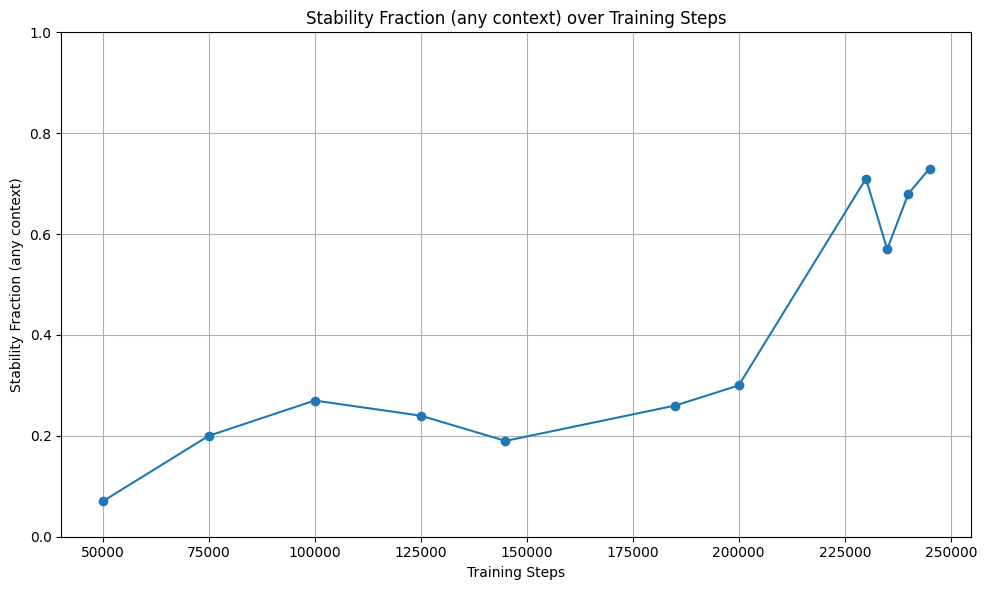

In [42]:
# Plot and save results
fig_all_contexts = plt.figure(figsize=(10, 6))
plt.plot(list(fracs.keys()), list(fracs.values()), marker='o')
plt.title('Stability Fraction (any context) over Training Steps')
plt.xlabel('Training Steps')
plt.ylabel('Stability Fraction (any context)')
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()
fig_all_contexts.savefig(os.path.join(output_dir, f'stability_fraction_any_context_100systems.png'))